<a href="https://colab.research.google.com/github/dmounika400/my-project/blob/feature-1/Regrations_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# EDA 1

In [ ]:
df=pd.read_csv("/content/titanic.csv.xls")
df.head(10)

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0
5,6,"Moran, Mr. James",3,male,NaN,0,0,330877,8.4583,NaN,Q,0
6,7,"McCarthy, Mr. Timothy J",1,male,54.0,0,0,17463,51.8625,E46,S,0
7,8,"Palsson, Master. Gosta Leonard",3,male,2.0,3,1,349909,21.0750,NaN,S,0
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",3,female,27.0,0,2,347742,11.1333,NaN,S,1
9,10,"Nasser, Mrs. Nicholas (Adele Achem)",2,female,14.0,1,0,237736,30.0708,NaN,C,1


In [ ]:
df.shape

(891, 12)

In [ ]:
len(df)

891

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.dtypes

,0
PassengerId,int64
Name,object
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [ ]:
duplicates=df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208,0.383838
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429,0.486592
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Name,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [ ]:
df.isnull().mean()*100

,0
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,77.104377


In [ ]:
df.describe(include=['object'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


# 1. simple linear Regression

In [ ]:
# step 1: Importing Necessary Libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
# step 2: Creating the Dataset

df.head(10)

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0
5,6,"Moran, Mr. James",3,male,NaN,0,0,330877,8.4583,NaN,Q,0
6,7,"McCarthy, Mr. Timothy J",1,male,54.0,0,0,17463,51.8625,E46,S,0
7,8,"Palsson, Master. Gosta Leonard",3,male,2.0,3,1,349909,21.0750,NaN,S,0
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",3,female,27.0,0,2,347742,11.1333,NaN,S,1
9,10,"Nasser, Mrs. Nicholas (Adele Achem)",2,female,14.0,1,0,237736,30.0708,NaN,C,1


In [ ]:
print(df.columns)

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived',
       'Sex_1', 'Embarked_1', 'Embarked_2', 'Embarked_3'],
      dtype='object')


In [ ]:
print(X_train.dtypes)

PassengerId      int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
                ...   
Cabin_F4          bool
Cabin_G6          bool
Cabin_T           bool
Embarked_Q        bool
Embarked_S        bool
Length: 836, dtype: object


In [ ]:
print(X.isnull().sum())

PassengerId      0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
Sex_1            0
Embarked_1       0
Embarked_2       0
Embarked_3       0
dtype: int64


In [ ]:
X = df.drop("Survived", axis=1)
y = df["Survived"]


In [ ]:
# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.impute import SimpleImputer


In [ ]:
# Fill missing values
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [ ]:
# Train
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Displaying actual vs predicted test scores
print("Actual vs Predicted Test Scores for the Test Set:")
for actual, predicted in zip(y_test, y_pred):
    print(f"Actual: {actual}, Predicted: {predicted:.2f}")



Actual vs Predicted Test Scores for the Test Set:
Actual: 0, Predicted: 0.15
Actual: 0, Predicted: 0.10
Actual: 0, Predicted: 0.14
Actual: 1, Predicted: 0.98
Actual: 1, Predicted: 0.64
Actual: 1, Predicted: 0.44
Actual: 1, Predicted: 0.91
Actual: 1, Predicted: 0.95
Actual: 1, Predicted: 0.49
Actual: 1, Predicted: 0.65
Actual: 0, Predicted: 0.08
Actual: 1, Predicted: 0.71
Actual: 0, Predicted: 0.18
Actual: 1, Predicted: 0.90
Actual: 1, Predicted: 1.04
Actual: 0, Predicted: 0.71
Actual: 0, Predicted: 0.15
Actual: 0, Predicted: 0.29
Actual: 0, Predicted: 0.07
Actual: 1, Predicted: 0.32
Actual: 0, Predicted: 0.34
Actual: 1, Predicted: 1.03
Actual: 0, Predicted: 0.18
Actual: 0, Predicted: 0.44
Actual: 0, Predicted: 0.66
Actual: 1, Predicted: 0.89
Actual: 0, Predicted: 0.09
Actual: 1, Predicted: 0.66
Actual: 1, Predicted: 0.80
Actual: 0, Predicted: 0.63
Actual: 0, Predicted: 0.13
Actual: 1, Predicted: 0.64
Actual: 0, Predicted: 0.11
Actual: 1, Predicted: 0.44
Actual: 0, Predicted: 0.06
Actua

In [ ]:
y_pred

array([ 3.90746443e-15,  1.21115112e-14, -3.34259530e-15,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.36463080e-14,  1.00000000e+00,
       -4.83630344e-15,  1.00000000e+00,  1.00000000e+00,  1.17255355e-14,
        2.05519195e-14, -7.60112459e-15,  1.48932516e-14,  1.00000000e+00,
       -1.04111815e-13,  1.00000000e+00, -4.27208463e-15,  7.99300919e-14,
        2.30429825e-14,  1.00000000e+00,  1.38831030e-14,  1.00000000e+00,
        1.00000000e+00, -3.08628990e-15, -6.47585284e-14,  1.00000000e+00,
        2.19973779e-14,  1.00000000e+00,  9.16422147e-15,  1.00000000e+00,
        6.78775612e-15, -1.08375982e-13, -9.53371496e-14, -8.95676762e-14,
        1.00000000e+00, -7.22187067e-14,  4.91257397e-14, -3.48831207e-15,
        1.00000000e+00,  1.33660442e-14,  1.39677764e-14,  1.00000000e+00,
       -9.47946149e-14, -2.37304751e-15,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 10)
(179, 10)
(712,)
(179,)


In [ ]:
print(y_pred.shape)

(179,)


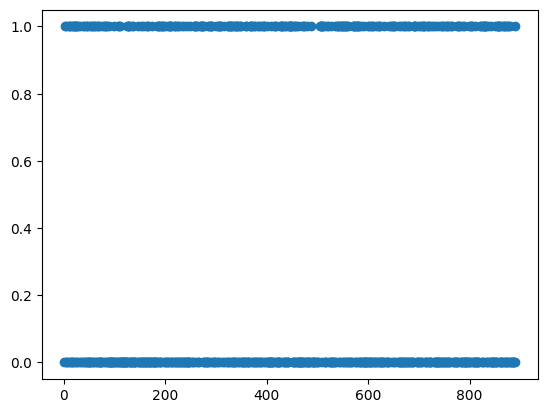

In [ ]:
plt.scatter(X_train.iloc[:, 0], y_train)

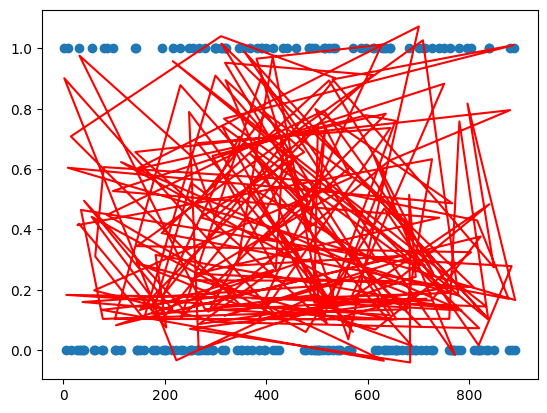

In [ ]:
y_pred = model.predict(X_test)

plt.scatter(X_test.iloc[:, 0], y_test)
plt.plot(X_test.iloc[:, 0], y_pred, color='red')

In [ ]:
# Step 8: Evaluating the Model Performance
# Calculate Mean Squared Error and R-Squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-Squared (R²): {r2:.2f}')

Mean Squared Error (MSE): 0.14
R-Squared (R²): 0.43


In [ ]:
# Step 9: Regression Metrics

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nRegression Metrics")
print("R2 Score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)
print("MAE      :", mae)


Regression Metrics
R2 Score : 0.42576716041901697
MSE      : 0.136026567598379
RMSE     : 0.3688177972907205
MAE      : 0.2878415791744483


In [ ]:
# Step 10 : Accuracy (Convert predictions to 0 or 1)

y_pred_class = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_class)

print("\nAccuracy :", accuracy)
print("Accuracy (%):", accuracy * 100)


Accuracy : 0.7932960893854749
Accuracy (%): 79.3296089385475


# 2.support vector regression (SVR)

In [ ]:
#1. Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [ ]:
#2. Loading the Data

df=pd.read_csv("/content/titanic.csv.xls")
df.head(10)

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0
5,6,"Moran, Mr. James",3,male,NaN,0,0,330877,8.4583,NaN,Q,0
6,7,"McCarthy, Mr. Timothy J",1,male,54.0,0,0,17463,51.8625,E46,S,0
7,8,"Palsson, Master. Gosta Leonard",3,male,2.0,3,1,349909,21.0750,NaN,S,0
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",3,female,27.0,0,2,347742,11.1333,NaN,S,1
9,10,"Nasser, Mrs. Nicholas (Adele Achem)",2,female,14.0,1,0,237736,30.0708,NaN,C,1


In [ ]:
X=df[['Name','Survived']].values
y=df['Embarked'].values

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.3, random_state=42)

In [ ]:
df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [ ]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Stabdardizing the features

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC

In [ ]:
import numpy as np

print(np.isnan(X_train).sum())

140


In [ ]:
print(np.isinf(X_train).sum())


0


In [ ]:
print(y_train.isnull().sum())
print(y_train.unique())

0
[0 1]


In [ ]:
print(type(X_train))
print(type(y_train))

import numpy as np
print(np.isnan(X_train).sum())
print(np.isinf(X_train).sum())

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
140
0


In [ ]:
import numpy as np

print(np.isnan(X_train).sum())


140


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Fill missing values
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scale the data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# Making predictions
y_pred=svm.predict(X_test)



In [ ]:
# Check accuracy

accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100: .2f}%")

Accuracy:  78.21%


In [ ]:
# Visualizing the Decision Boundary

def plot_decision_boundary(X,y, model):
  x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
  y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
  xx,yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


# 3. K-Nearest Neighbors Regression(KNR)

In [ ]:
#1. import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
#2. Load dataset
df.head(10)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_1,Embarked_1,Embarked_2,Embarked_3
0,1,3,22.0,1,0,7.2500,0,True,False,True,False
1,2,1,38.0,1,0,71.2833,1,False,False,False,False
2,3,3,26.0,0,0,7.9250,1,False,False,True,False
3,4,1,35.0,1,0,53.1000,1,False,False,True,False
4,5,3,35.0,0,0,8.0500,0,True,False,True,False
5,6,3,NaN,0,0,8.4583,0,True,True,False,False
6,7,1,54.0,0,0,51.8625,0,True,False,True,False
7,8,3,2.0,3,1,21.0750,0,True,False,True,False
8,9,3,27.0,0,2,11.1333,1,False,False,True,False
9,10,2,14.0,1,0,30.0708,1,False,False,False,False


In [ ]:
#3. Separate features and target
x=df.drop("Survived",axis=1)
y=df["Survived"]

In [ ]:
#4. Indentify numerical and categirical columns

num_cols=x.select_dtypes(include=["int64", "float64"]).columns
cat_cols=x.select_dtypes(include=["object"]).columns

In [ ]:
#5. preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))

])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [ ]:
#6. Create KNR model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("knr", KNeighborsRegressor(n_neighbors=5))
])

In [ ]:
#7. Split dataset

X_train, X_test_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train Model
model.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('knr', KNeighborsRegressor())])

In [ ]:
#9. Predict
y_pred = model.predict(X_test)

In [ ]:
#10. Display prediction values

print("\nprediction values:")
print(y_pred)


prediction values:
[0.2 0.8 0.  0.4 0.2 0.8 0.4 0.6 0.4 0.6 0.4 0.4 0.2 0.  0.6 0.4 0.4 0.2
 0.  0.  0.4 0.4 0.4 0.2 0.4 0.4 0.2 0.  0.4 0.4 0.2 0.4 0.2 0.  0.2 0.2
 0.2 0.2 0.4 0.2 0.2 0.2 0.2 0.4 0.4 0.2 0.2 0.2 0.2 0.4 0.6 0.2 0.2 0.6
 0.6 1.  0.4 0.8 0.2 0.2 0.  0.6 0.6 0.2 0.2 0.2 0.4 0.  0.2 1.  0.8 0.8
 0.6 0.4 0.2 0.2 0.  0.8 0.4 0.4 0.2 0.  0.8 0.  0.4 0.4 0.6 0.6 0.4 0.2
 0.4 0.8 0.4 0.2 0.4 0.4 0.8 0.4 0.8 0.4 0.6 0.2 0.8 0.  0.2 0.6 0.  0.6
 0.4 0.6 0.2 0.4 0.4 0.4 0.4 0.2 0.2 0.6 0.8 0.4 0.2 0.6 0.6 0.4 0.2 0.6
 0.2 0.4 0.8 0.  0.4 0.2 0.  0.6 0.6 0.4 1.  0.  0.  0.2 0.2 0.6 0.4 0.6
 0.6 0.6 0.2 0.6 0.6 0.  0.4 0.4 0.2 0.2 0.4 0.2 0.4 0.4 0.4 0.  0.4 0.2
 0.  0.8 0.4 0.6 0.2 0.2 0.  0.6 0.2 0.  0.6 0.4 0.2 0.  0.2 0.  0.2]


In [ ]:
#11. model evalution

r2=r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nR2 Score:", r2)
print("RMSE:",rmse)


R2 Score: 0.054548262548262394
RMSE: 0.4788253784176021


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.4022346368715084
MSE : 0.22927374301675982
RMSE: 0.4788253784176021
R2 Score: 0.054548262548262394


In [ ]:
y_pred = model.predict(X_test)   # values like 0.67, 0.23

In [ ]:
y_pred_binary = (y_pred >= 0.5).astype(int)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_binary)
print("Accuracy:", accuracy)

Accuracy: 0.659217877094972


# 4. Decision Tree Regression(DTR)

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
#step2. load the dataset and display
df.head(10)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_1,Embarked_1,Embarked_2,Embarked_3
0,1,3,22.0,1,0,7.2500,0,True,False,True,False
1,2,1,38.0,1,0,71.2833,1,False,False,False,False
2,3,3,26.0,0,0,7.9250,1,False,False,True,False
3,4,1,35.0,1,0,53.1000,1,False,False,True,False
4,5,3,35.0,0,0,8.0500,0,True,False,True,False
5,6,3,NaN,0,0,8.4583,0,True,True,False,False
6,7,1,54.0,0,0,51.8625,0,True,False,True,False
7,8,3,2.0,3,1,21.0750,0,True,False,True,False
8,9,3,27.0,0,2,11.1333,1,False,False,True,False
9,10,2,14.0,1,0,30.0708,1,False,False,False,False


In [ ]:
# Step 3: Separate Features and Target

X = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
# Step 4: Find Numerical and Categorical Columns
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


In [ ]:
# Step 5: Preprocessing

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])



In [ ]:
# Step 6: Create Decision Tree Regressor Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("dtr", DecisionTreeRegressor(random_state=42))
])


In [ ]:
# Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Step 8: Train Model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('dtr', DecisionTreeRegressor(random_state=42))])

In [ ]:
# Step 9: Predict
y_pred = model.predict(X_test)

In [ ]:
# Step 10: Prediction Values
print("\nPrediction Values:")
print(y_pred)


Prediction Values:
[1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0.
 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1.
 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1.
 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0.
 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1.
 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1.]


In [ ]:
# Step 11: Evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nR2 Score:", r2)
print("RMSE:", rmse)


R2 Score: -0.38223938223938236
RMSE: 0.5789607333198487


In [ ]:
accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100: .2f}%")

Accuracy:  66.48%


#5. Random Forest Regresion (RFR)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
print(df.head())

   PassengerId  Pclass   Age  SibSp  Parch     Fare  Survived  Sex_1  \
0            1       3  22.0      1      0   7.2500         0   True   
1            2       1  38.0      1      0  71.2833         1  False   
2            3       3  26.0      0      0   7.9250         1  False   
3            4       1  35.0      1      0  53.1000         1  False   
4            5       3  35.0      0      0   8.0500         0   True   

   Embarked_1  Embarked_2  Embarked_3  
0       False        True       False  
1       False       False       False  
2       False        True       False  
3       False        True       False  
4       False        True       False  


In [ ]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("rfr", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('rfr', RandomForestRegressor(random_state=42))])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("\nPrediction Values:")
print(y_pred)


Prediction Values:
[0.23 0.71 0.14 0.86 0.42 0.82 0.66 0.44 0.54 0.45 0.6  0.06 0.04 0.06
 0.7  0.7  0.88 0.06 0.6  0.09 0.09 0.6  0.15 0.19 0.1  0.04 0.36 0.43
 0.13 0.55 0.09 0.47 0.52 0.07 0.39 0.32 0.57 0.04 0.56 0.01 0.15 0.2
 0.11 0.34 0.18 0.15 0.22 0.06 0.21 0.68 0.82 0.77 0.15 0.82 0.21 0.76
 0.63 0.57 0.31 0.2  0.18 0.91 0.77 0.31 0.05 0.2  0.35 0.62 0.23 0.91
 0.66 0.59 0.83 0.91 0.16 0.4  0.1  0.85 0.82 0.37 0.16 0.59 0.75 0.67
 0.11 0.2  0.89 0.64 0.   0.04 0.41 0.   0.55 0.5  0.07 0.63 0.67 0.08
 0.72 0.31 0.15 0.03 0.51 0.04 0.19 0.31 0.19 0.22 0.14 0.24 0.24 0.13
 0.74 0.43 0.36 0.28 0.18 0.67 0.74 0.08 0.67 0.77 0.53 0.91 0.37 0.56
 0.61 0.57 0.34 0.02 0.73 0.2  0.07 0.87 0.84 0.36 0.91 0.2  0.05 0.12
 0.03 0.78 0.51 0.51 0.19 0.45 0.15 0.65 0.26 0.01 0.15 0.2  0.14 0.27
 0.09 0.05 0.73 0.64 0.6  0.31 0.45 0.43 0.13 0.77 0.41 0.46 0.62 0.32
 0.02 0.14 0.45 0.78 0.47 0.63 0.07 0.19 0.09 0.64 0.6 ]


In [ ]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(result.head(20))


Actual vs Predicted:
    Actual  Predicted
0        1       0.23
1        0       0.71
2        0       0.14
3        1       0.86
4        1       0.42
5        1       0.82
6        1       0.66
7        0       0.44
8        1       0.54
9        1       0.45
10       0       0.60
11       0       0.06
12       0       0.04
13       0       0.06
14       0       0.70
15       1       0.70
16       1       0.88
17       1       0.06
18       0       0.60
19       0       0.09


In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("R2 Score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)
print("MAE      :", mae)


Model Performance
R2 Score : 0.2680328314028314
MSE      : 0.17750335195530725
RMSE     : 0.4213114666791153
MAE      : 0.34195530726256984


In [ ]:
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('rfr', RandomForestRegressor(random_state=42))])


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8268156424581006


#6. Extreme Gradient Boosting Regression(XG Boost r)


In [ ]:
pip install xgboost


In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

In [ ]:
print(df.head())

   PassengerId  Pclass   Age  SibSp  Parch     Fare  Survived  Sex_1  \
0            1       3  22.0      1      0   7.2500         0   True   
1            2       1  38.0      1      0  71.2833         1  False   
2            3       3  26.0      0      0   7.9250         1  False   
3            4       1  35.0      1      0  53.1000         1  False   
4            5       3  35.0      0      0   8.0500         0   True   

   Embarked_1  Embarked_2  Embarked_3  
0       False        True       False  
1       False       False       False  
2       False        True       False  
3       False        True       False  
4       False        True       False  


In [ ]:
# Step 3: Separate Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
# Step 4: Identify Numerical and Categorical Columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


In [ ]:
# Step 5: Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])



In [ ]:
# Step 6: Create XGBoost Regressor Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [ ]:
# Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Step 8: Train Model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dt...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
# Step 9: Predict
y_pred = model.predict(X_test)

print("\nPrediction Values:")
print(y_pred)


Prediction Values:
[ 3.0907384e-01  4.7887313e-01  2.7400079e-01  8.3035594e-01
  2.9376939e-01  7.1869892e-01  3.0220103e-01  3.6801749e-01
  3.9735699e-01  4.2606080e-01  5.9534061e-01  4.5784220e-02
  1.8615256e-01  1.7915010e-01  4.6498007e-01  4.8972639e-01
  9.1391540e-01  1.7551821e-01  3.1800172e-01  5.9510231e-02
  1.7658919e-01  5.4427058e-01  2.4021064e-01  1.3405824e-01
  2.5949621e-01  9.6921004e-02  3.6026388e-01  3.5781497e-01
  2.0509318e-01  2.8879863e-01  1.3966265e-01  3.1343392e-01
  4.4665128e-01  2.0605029e-01  1.5699334e-01  2.1829581e-01
  4.0842223e-01  2.6098639e-01  4.2661834e-01  9.3130484e-02
  2.5790739e-01  1.0621088e-01  1.4449456e-01  1.8180606e-01
  2.8051102e-01  4.3673033e-01  1.8473586e-01  2.2345175e-01
  2.8380731e-01  7.5810176e-01  9.4766152e-01  7.0230454e-01
  5.6176767e-02  8.7667966e-01  1.5679218e-01  7.7831143e-01
  4.7494543e-01  6.8447065e-01  3.7681112e-01  4.0958121e-01
  2.6955971e-01  8.5427934e-01  4.8494652e-01  3.1412727e-01
  2.

In [ ]:
# Step 10: Actual vs Predicted
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(result.head(20))


Actual vs Predicted:
    Actual  Predicted
0        1   0.309074
1        0   0.478873
2        0   0.274001
3        1   0.830356
4        1   0.293769
5        1   0.718699
6        1   0.302201
7        0   0.368017
8        1   0.397357
9        1   0.426061
10       0   0.595341
11       0   0.045784
12       0   0.186153
13       0   0.179150
14       0   0.464980
15       1   0.489726
16       1   0.913915
17       1   0.175518
18       0   0.318002
19       0   0.059510


In [ ]:
# Step 11: Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("R2 Score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)
print("MAE      :", mae)


Model Performance
R2 Score : 0.2969847321510315
MSE      : 0.17048247158527374
RMSE     : 0.4128952307611142
MAE      : 0.357084184885025


In [ ]:
from sklearn.metrics import accuracy_score

# Convert regression predictions to 0 or 1
y_pred_class = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7430167597765364
Accuracy (%): 74.30167597765363


#7.Ada Boost Regression (AdaR)

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# Step 2: Display Dataset
print(df.head())

   PassengerId  Pclass   Age  SibSp  Parch     Fare  Survived  Sex_1  \
0            1       3  22.0      1      0   7.2500         0   True   
1            2       1  38.0      1      0  71.2833         1  False   
2            3       3  26.0      0      0   7.9250         1  False   
3            4       1  35.0      1      0  53.1000         1  False   
4            5       3  35.0      0      0   8.0500         0   True   

   Embarked_1  Embarked_2  Embarked_3  
0       False        True       False  
1       False       False       False  
2       False        True       False  
3       False        True       False  
4       False        True       False  


In [ ]:
# Step 3: Separate Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]


In [ ]:
# Step 4: Numerical and Categorical Columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


In [ ]:
# Step 5: Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [ ]:
# Step 6: AdaBoost Regressor Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("ada", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])


In [ ]:
# Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Step 8: Train Model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('ada',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                                   learning_rate=0.1, n_estimators=100,
                                   random_state=42))])

In [ ]:
# Step 9: Predict
y_pred = model.predict(X_test)

print("\nPrediction Values:")
print(y_pred)


Prediction Values:
[0.38095238 0.43684211 0.30864198 0.95833333 0.40295749 0.64912281
 0.36397059 0.40155945 0.37106918 0.43684211 0.48660714 0.22727273
 0.28709677 0.33716475 0.45182724 0.49115044 0.61728395 0.31764706
 0.44247788 0.41666667 0.35738832 0.47154472 0.35087719 0.29139073
 0.37752161 0.23       0.43684211 0.43684211 0.13888889 0.35987261
 0.30232558 0.35738832 0.46511628 0.35087719 0.32817337 0.36046512
 0.44444444 0.35738832 0.46341463 0.30232558 0.43462898 0.2810219
 0.29139073 0.32817337 0.39252336 0.33333333 0.32258065 0.33024691
 0.33024691 0.67391304 0.75609756 0.65384615 0.36826347 0.70707071
 0.35087719 0.67647059 0.41666667 0.62295082 0.43103448 0.33716475
 0.33716475 0.75757576 0.47150259 0.43103448 0.35738832 0.40893471
 0.4640884  0.33571429 0.33333333 0.63809524 0.47391304 0.63043478
 0.47154472 0.67346939 0.32258065 0.37752161 0.32258065 0.51851852
 0.452      0.40804598 0.22649573 0.41916168 0.65536723 0.32817337
 0.42162162 0.47154472 0.67391304 0.6304347

In [ ]:
# Step 10: Actual vs Predicted
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(result.head(20))



Actual vs Predicted:
    Actual  Predicted
0        1   0.380952
1        0   0.436842
2        0   0.308642
3        1   0.958333
4        1   0.402957
5        1   0.649123
6        1   0.363971
7        0   0.401559
8        1   0.371069
9        1   0.436842
10       0   0.486607
11       0   0.227273
12       0   0.287097
13       0   0.337165
14       0   0.451827
15       1   0.491150
16       1   0.617284
17       1   0.317647
18       0   0.442478
19       0   0.416667


In [ ]:
# Step 11: Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("R2 Score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)
print("MAE      :", mae)


Model Performance
R2 Score : 0.21992182326178844
MSE      : 0.18917035776835628
RMSE     : 0.4349371883023528
MAE      : 0.41287172738708827


In [ ]:
from sklearn.metrics import accuracy_score

# Convert predicted values to binary (0 or 1)
y_pred_class = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7262569832402235
Accuracy (%): 72.62569832402235


#8. Cat Boost Regression (CatR)


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

In [ ]:
# Step 2: Display Dataset
print(df.head())

   PassengerId  Pclass   Age  SibSp  Parch     Fare  Survived  Sex_1  \
0            1       3  22.0      1      0   7.2500         0   True   
1            2       1  38.0      1      0  71.2833         1  False   
2            3       3  26.0      0      0   7.9250         1  False   
3            4       1  35.0      1      0  53.1000         1  False   
4            5       3  35.0      0      0   8.0500         0   True   

   Embarked_1  Embarked_2  Embarked_3  
0       False        True       False  
1       False       False       False  
2       False        True       False  
3       False        True       False  
4       False        True       False  


In [ ]:
# Step 3: Separate Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
# Step 4: Numerical and Categorical Columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [ ]:
# Step 5: Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [ ]:
# Step 6: Create CatBoost Regressor Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("catr", CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_state=42,
        verbose=0
    ))
])

In [ ]:
# Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Step 8: Train Model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('catr',
                 CatBoostRegressor(depth=6, iterations=100, learning_rate=0.1, loss_function='RMSE', random_state=42, verbose=0))])

In [ ]:
# Step 9: Predict
y_pred = model.predict(X_test)

# Prediction Values
print("\nPrediction Values:")
print(y_pred)


Prediction Values:
[ 0.30608131  0.46390922  0.21675746  0.87415847  0.33865489  0.70366522
  0.40331173  0.36589019  0.36164041  0.57848836  0.56664088  0.04456302
  0.18750063  0.14949651  0.55002943  0.76540237  0.7473509   0.16841262
  0.37164064  0.28901211  0.24534925  0.47880692  0.23526319  0.13042809
  0.27635827  0.19226214  0.44760773  0.41121349  0.15964286  0.26429869
  0.18145238  0.33459186  0.47528629  0.26976614  0.15928039  0.27815283
  0.44071107  0.31049117  0.56366236  0.10252239  0.42132483  0.18574635
  0.1401938   0.22268345  0.31798758  0.21604807  0.17930973  0.23639207
  0.19212071  0.71756519  0.72301671  0.73154852  0.16882331  0.92977418
  0.21257284  0.80730303  0.46486352  0.65452884  0.43340822  0.33216324
  0.25879919  0.79588188  0.57041252  0.36548497  0.31049117  0.27905996
  0.46727601  0.26410785  0.26382183  0.73202362  0.63780816  0.67522789
  0.69581041  0.85335881  0.15452998  0.22345149  0.20195038  0.67610196
  0.51909787  0.42883073  0.168

In [ ]:
# Step 10: Actual vs Predicted
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(result.head(20))


Actual vs Predicted:
    Actual  Predicted
0        1   0.306081
1        0   0.463909
2        0   0.216757
3        1   0.874158
4        1   0.338655
5        1   0.703665
6        1   0.403312
7        0   0.365890
8        1   0.361640
9        1   0.578488
10       0   0.566641
11       0   0.044563
12       0   0.187501
13       0   0.149497
14       0   0.550029
15       1   0.765402
16       1   0.747351
17       1   0.168413
18       0   0.371641
19       0   0.289012


In [ ]:
# Step 11: Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("R2 Score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)
print("MAE      :", mae)


Model Performance
R2 Score : 0.3098204995742271
MSE      : 0.16736976743260995
RMSE     : 0.40910850325141124
MAE      : 0.3603617704343932


In [ ]:
from sklearn.metrics import accuracy_score

# Convert predicted values into 0 or 1
y_pred_class = (y_pred >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7597765363128491
Accuracy (%): 75.97765363128491
